In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mdmahfuzsumon/large-scale-financial-fraud-dataset/improved_fraud_dataset.csv


In [3]:
df = pd.read_csv("/kaggle/input/datasets/mdmahfuzsumon/large-scale-financial-fraud-dataset/improved_fraud_dataset.csv")

In [4]:
df.head(10)

,organization,transaction_id,user_id,user_account_age_days,kyc_verified,payment_method,card_type,transaction_amount,currency,fee_amount,...,device_type,operating_system,browser,merchant_category,transaction_type,otp_used,is_fraud,hour,is_night,time_diff
0,FinovaTech_000,TXN00000044,FinovaTech_000_U0000,1670,1,bkash,debit,1553.81,BDT,31.08,...,mobile,Windows,Safari,fashion,purchase,1,0,8,0,0.0
1,FinovaTech_000,TXN00000004,FinovaTech_000_U0000,1670,1,bkash,debit,136.49,BDT,2.73,...,desktop,Android,Edge,grocery,withdrawal,0,0,6,0,1719608.0
2,FinovaTech_000,TXN00000033,FinovaTech_000_U0000,1670,1,card,credit,3432.40,BDT,68.65,...,tablet,iOS,Safari,electronics,transfer,1,0,19,0,827250.0
3,FinovaTech_000,TXN00000050,FinovaTech_000_U0000,1670,1,bkash,credit,503.59,BDT,10.07,...,tablet,Windows,Chrome,fashion,purchase,1,0,19,0,1035744.0
4,FinovaTech_000,TXN00000047,FinovaTech_000_U0000,1670,0,bank,credit,1908.35,BDT,38.17,...,tablet,Windows,Chrome,grocery,transfer,1,0,12,0,408465.0
5,FinovaTech_000,TXN00000024,FinovaTech_000_U0000,1670,0,bkash,debit,2841.70,BDT,56.83,...,tablet,iOS,Safari,electronics,withdrawal,1,0,0,1,1076902.0
6,FinovaTech_000,TXN00000032,FinovaTech_000_U0000,1670,1,nagad,credit,6.29,BDT,0.13,...,mobile,Windows,Edge,travel,purchase,1,0,18,0,1361224.0
7,FinovaTech_000,TXN00000023,FinovaTech_000_U0000,1670,1,bank,debit,1001.03,BDT,20.02,...,tablet,Android,Chrome,fashion,transfer,1,0,1,1,630355.0
8,FinovaTech_000,TXN00000005,FinovaTech_000_U0000,1670,1,bank,credit,1155.95,BDT,23.12,...,tablet,iOS,Edge,fashion,withdrawal,1,0,9,0,1759099.0
9,FinovaTech_000,TXN00000002,FinovaTech_000_U0000,1670,0,card,credit,3791.36,BDT,75.83,...,desktop,Windows,Safari,electronics,transfer,0,0,22,0,1256260.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   organization           1000000 non-null  object 
 1   transaction_id         1000000 non-null  object 
 2   user_id                1000000 non-null  object 
 3   user_account_age_days  1000000 non-null  int64  
 4   kyc_verified           1000000 non-null  int64  
 5   payment_method         1000000 non-null  object 
 6   card_type              1000000 non-null  object 
 7   transaction_amount     1000000 non-null  float64
 8   currency               1000000 non-null  object 
 9   fee_amount             1000000 non-null  float64
 10  transaction_timestamp  1000000 non-null  object 
 11  day_of_week            1000000 non-null  object 
 12  city                   1000000 non-null  object 
 13  country                1000000 non-null  object 
 14  device_type        

In [6]:
df.isnull().sum()

organization             0
transaction_id           0
user_id                  0
user_account_age_days    0
kyc_verified             0
payment_method           0
card_type                0
transaction_amount       0
currency                 0
fee_amount               0
transaction_timestamp    0
day_of_week              0
city                     0
country                  0
device_type              0
operating_system         0
browser                  0
merchant_category        0
transaction_type         0
otp_used                 0
is_fraud                 0
hour                     0
is_night                 0
time_diff                0
dtype: int64

In [7]:
df.shape

(1000000, 24)

In [8]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
999995    False
999996    False
999997    False
999998    False
999999    False
Length: 1000000, dtype: bool

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   organization           1000000 non-null  object 
 1   transaction_id         1000000 non-null  object 
 2   user_id                1000000 non-null  object 
 3   user_account_age_days  1000000 non-null  int64  
 4   kyc_verified           1000000 non-null  int64  
 5   payment_method         1000000 non-null  object 
 6   card_type              1000000 non-null  object 
 7   transaction_amount     1000000 non-null  float64
 8   currency               1000000 non-null  object 
 9   fee_amount             1000000 non-null  float64
 10  transaction_timestamp  1000000 non-null  object 
 11  day_of_week            1000000 non-null  object 
 12  city                   1000000 non-null  object 
 13  country                1000000 non-null  object 
 14  device_type        

**DATA ANALYSIS**

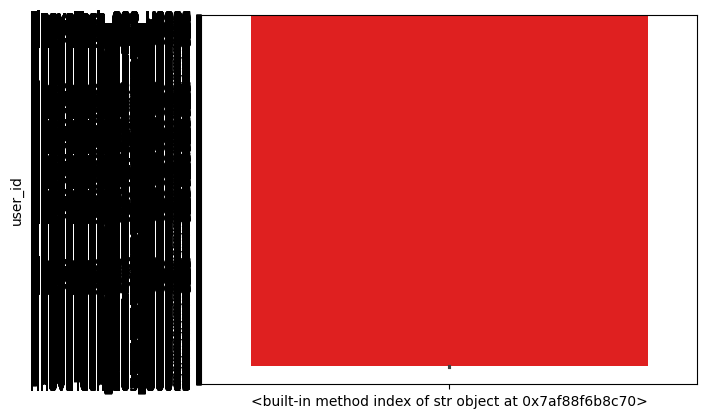

In [17]:
plt.figure()
sns.barplot(x='kyc_verified'.index, y = 'user_id', data = df, color = 'red')
plt.show()

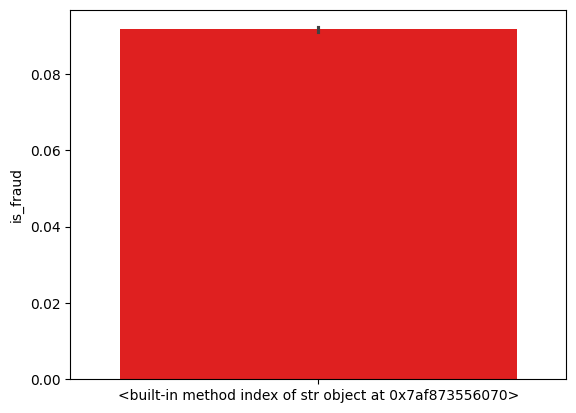

In [19]:
plt.figure()
sns.barplot(x='is_fraud'.index, y = 'is_fraud', data = df, color = 'red')
plt.show()

In [22]:
cols_to_fix = ['operating_system', 'device_type', 'browser', 'payment_method']
for col in cols_to_fix:
    df[col]=df[col].astype('category')

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype   
---  ------                 --------------    -----   
 0   organization           1000000 non-null  object  
 1   transaction_id         1000000 non-null  object  
 2   user_id                1000000 non-null  object  
 3   user_account_age_days  1000000 non-null  int64   
 4   kyc_verified           1000000 non-null  int64   
 5   payment_method         1000000 non-null  category
 6   card_type              1000000 non-null  object  
 7   transaction_amount     1000000 non-null  float64 
 8   currency               1000000 non-null  object  
 9   fee_amount             1000000 non-null  float64 
 10  transaction_timestamp  1000000 non-null  object  
 11  day_of_week            1000000 non-null  object  
 12  city                   1000000 non-null  object  
 13  country                1000000 non-null  object  
 14  dev

In [26]:
payment_risk = df.groupby(['payment_method', 'card_type'])['is_fraud'].mean().reset_index()
payment_risk = payment_risk.sort_values(by='is_fraud', ascending = False)
payment_risk.head

/tmp/ipykernel_55/3847751865.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  payment_risk = df.groupby(['payment_method', 'card_type'])['is_fraud'].mean().reset_index()


<bound method NDFrame.head of   payment_method card_type  is_fraud
5           card     debit  0.092603
3          bkash     debit  0.091991
2          bkash    credit  0.091981
4           card    credit  0.091935
7          nagad     debit  0.091813
1           bank     debit  0.091255
0           bank    credit  0.091125
6          nagad    credit  0.090972>

/tmp/ipykernel_55/4225384725.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = df.groupby('operating_system')['is_fraud'].mean().sort_values(ascending=False).index
/tmp/ipykernel_55/4225384725.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x= 'operating_system', y='is_fraud', palette = 'viridis')


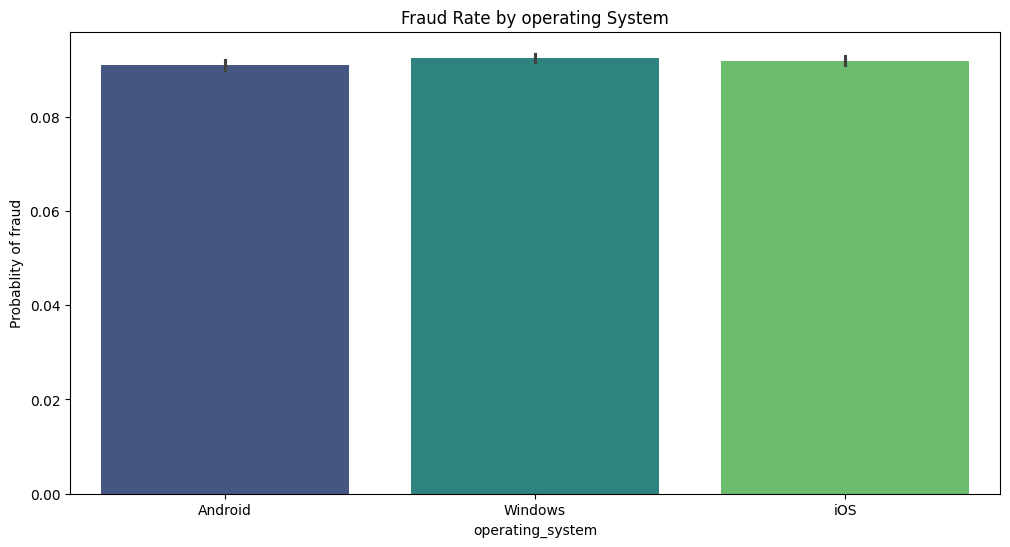

In [29]:
plt.figure(figsize =(12,6))
order = df.groupby('operating_system')['is_fraud'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x= 'operating_system', y='is_fraud', palette = 'viridis')
plt.title('Fraud Rate by operating System')
plt.ylabel('Probablity of fraud')
plt.show()

/tmp/ipykernel_55/69787513.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_data = df.pivot_table(index= 'merchant_category', columns = 'device_type', values = 'is_fraud', aggfunc='mean')


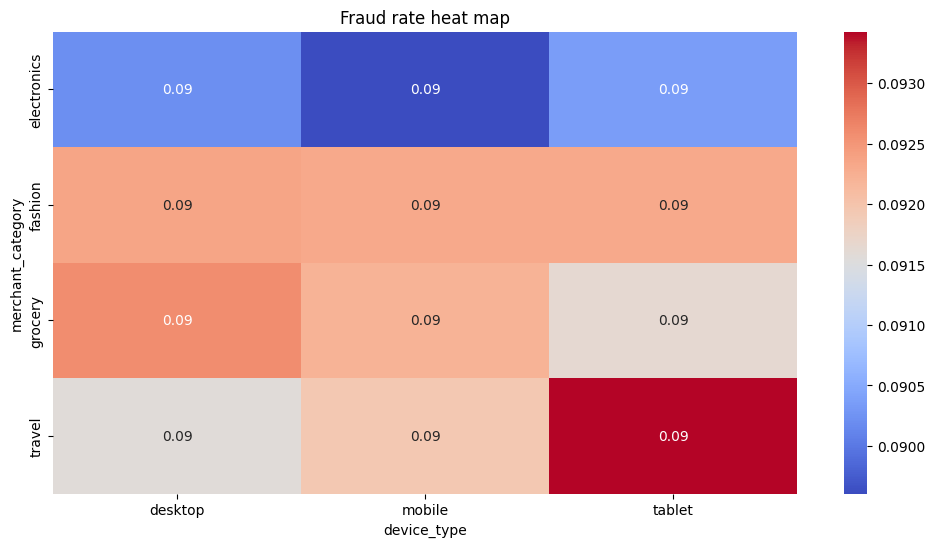

In [31]:
pivot_data = df.pivot_table(index= 'merchant_category', columns = 'device_type', values = 'is_fraud', aggfunc='mean')
plt.figure(figsize=(12,6))
sns.heatmap(pivot_data, annot = True, cmap = 'coolwarm', fmt='.2f')
plt.title('Fraud rate heat map')
plt.show()

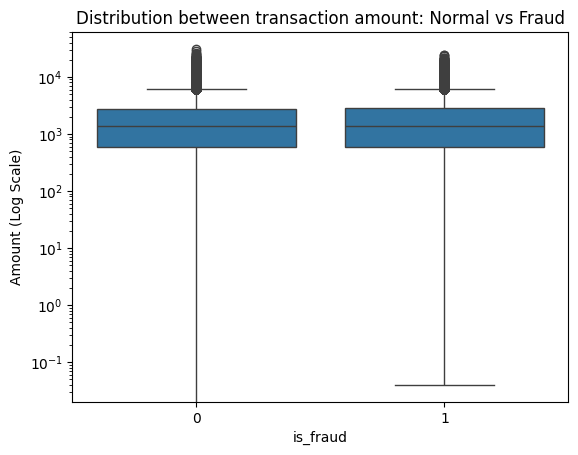

In [35]:
plt.figure()
sns.boxplot(x='is_fraud', y= 'transaction_amount', data=df)
plt.yscale('log')
plt.title('Distribution between transaction amount: Normal vs Fraud')
plt.ylabel('Amount (Log Scale)')
plt.show()

/tmp/ipykernel_55/3425710540.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_risky_countries.index, y = top_risky_countries['mean'], palette = 'magma')


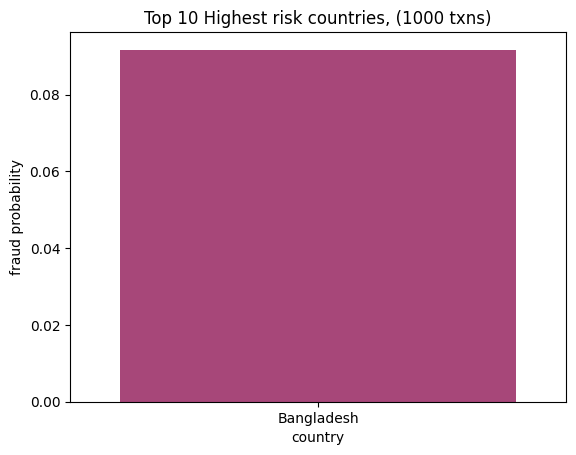

In [41]:
country_stats=df.groupby('country')['is_fraud'].agg(['count', 'mean']).sort_values(by='mean', ascending = False)
top_risky_countries =country_stats[country_stats['count']>1000].head(10)
plt.figure()
sns.barplot(x=top_risky_countries.index, y = top_risky_countries['mean'], palette = 'magma')
plt.title('Top 10 Highest risk countries, (1000 txns)')
plt.ylabel('fraud probability')
plt.show()

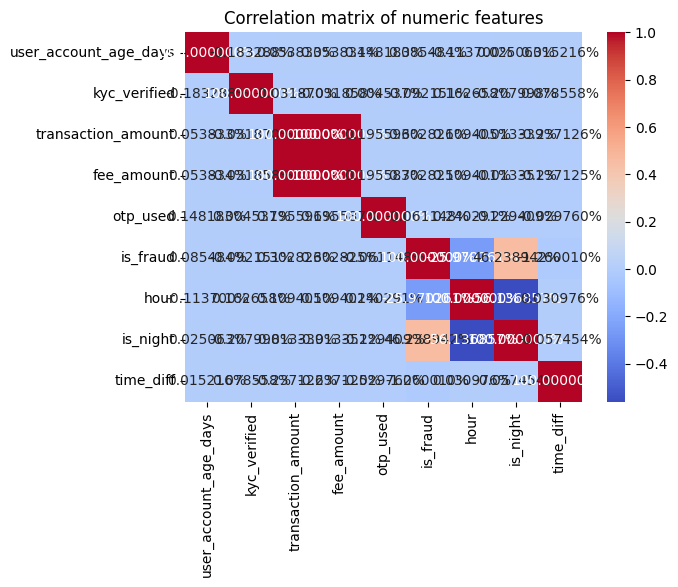

In [46]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix= df[numeric_cols].corr()
#plt.figure(figsize(10,6))
sns.heatmap(corr_matrix, annot=True, cmap = 'coolwarm', fmt = '2%')
plt.title('Correlation matrix of numeric features')
plt.show()

/tmp/ipykernel_55/1803869075.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_risk = df.groupby('age_group')['is_fraud'].mean().reset_index()


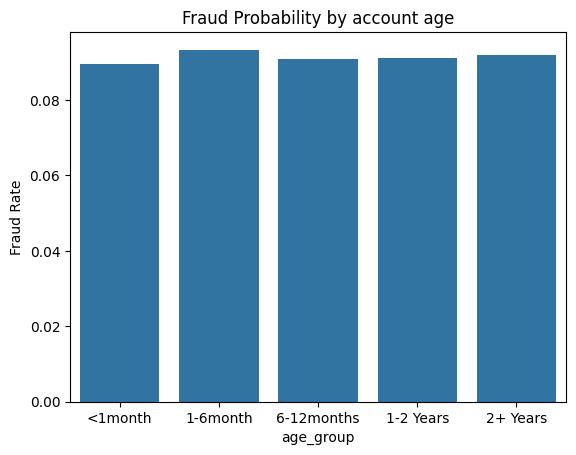

In [50]:
#account seniority vs Risk
df['age_group'] =pd.cut(df['user_account_age_days'], bins=[0,30, 180, 365, 730, 10000], labels=['<1month', '1-6month', '6-12months', '1-2 Years', '2+ Years'])
age_risk = df.groupby('age_group')['is_fraud'].mean().reset_index()
plt.figure()
sns.barplot(data = age_risk, x='age_group', y='is_fraud')
plt.title('Fraud Probability by account age')
plt.ylabel('Fraud Rate')
plt.show()

In [52]:
#Velocity Analysis
fast_txns= df[df['time_diff']<300]
velocity_fraud_rate = fast_txns['is_fraud'].mean()
overall_fraud_rate = df['is_fraud'].mean()
print(velocity_fraud_rate, overall_fraud_rate)

0.29534676941315946 0.09171


In [59]:
#Z-Score
#user_mean = df.groupby('user_id')['transaction_amount'].transform('mean')
#user_std = df.groupby('user_id')['transaction_amount'].transform('std')
#df['amount_zscore'] = (df['transaction_amount']-user_mean)/(user_std+1e-6)
#zscore_risk = df.groupby(pd.cut(df['amount_zscore'], bins=[-1,0,1,2, 3,5,10])).mean()
#zscore_risk

**MACHINE LEARNING ALGORITHMS**

In [62]:
#checking anomally before heading for actual machine learning 
from sklearn.ensemble import IsolationForest
anomaly_features=['transaction_amount', 'user_account_age_days', 'hour', 'time_diff']
iso_forest = IsolationForest(n_estimators=100, contamination = 0.01, random_state = 42, n_jobs = -1)
df['anomally_score'] = iso_forest.fit_predict(df[anomaly_features])
df['is_anomaly'] = df['anomally_score'].map({1:0,-1:1})


In [67]:
#using logistic regression model 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ['user_account_age_days', "kyc_verified", "transaction_amount","hour", "is_night", 'is_anomaly', 'payment_method']
x = pd.get_dummies(df[features], columns=['payment_method'], drop_first= True)
y = df ['is_fraud']
scaler =StandardScaler()
x_scaled = scaler.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
log_reg = LogisticRegression (class_weight="balanced", max_iter=1000)
log_reg.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [68]:
#Doing prediction and checking the model
y_pred = log_reg.predict(x_test)
y_pred

array([1, 0, 0, ..., 0, 0, 1])

In [70]:
#plotting confusion matrix and roc curve and classification report  for the above linear regression model
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


print("\nROC AUC Curve:")
roc_score = roc_auc_score(y_test, log_reg.predict_proba(x_test)[:,-1])
roc_score


Confusion matrix:
[[141120  40528]
 [   896  17456]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.78      0.87    181648
           1       0.30      0.95      0.46     18352

    accuracy                           0.79    200000
   macro avg       0.65      0.86      0.66    200000
weighted avg       0.93      0.79      0.83    200000


ROC AUC Curve:


np.float64(0.8641761634072579)

In [ ]:
#saving the model
model.save('fraud_detection_model.h5')